## Nguồn gốc của Dataset

### Bài báo khởi nguồn: DoWTS

- Thách thức lớn nhất cho giới nghiên cứu Denial of Wallet là sự thiếu hụt dữ liệu huấn luyện. Rất khó để thu thập dữ liệu log thực tế của các cuộc tấn công DoW vì nạn nhân sẽ phải trả một khoản tiền khổng lồ (tiền thật) để duy trì hệ thống trong lúc đo lường các cuộc tấn công này.
- **Vector tấn công chính: "Leech Attack"**. Kẻ tấn công gửi các request (thường qua các API endpoints) ở một tốc độ rất chậm và dàn trải trong một thời gian dài (có thể lên tới hàng tháng). Nó giống như nguyên lý "luộc ếch" (boiling the frog), con ếch sẽ bị nấu từ từ, và nó sẽ bị nấu chín mà không biết.
- Để giải quyết bài toán thiếu dữ liệu, nhóm tác giả phát triển DoWTS (Denial-of-Wallet Test Simulator), một công cụ tạo dữ liệu tổng hợp (synthetic data). Nó gồm 2 thành phần chính:
    - **Serverless Platform Emulator (SPE)**: Giả lập cấu hình, thời gian chạy và tính toán chi phí theo công thức thực tế của 4 nền tảng lớn (AWS Lambda, Google Cloud Functions, Azure, IBM).
    - **Usage Generator**: Trái tim của hệ thống, quản lý thời gian invoke hàm, sinh log và lưu vào cơ sở dữ liệu. Nó tạo ra 2 loại traffic:
        - **Traffic nền (Baseline/Legitimate)**, được sinh ra dựa trên việc phân tích các dataset thực tế của các trang thương mại điện tử.
        - **Traffic tấn công (Attack)**: Mô phỏng các botnet thực hiện Leech attack với 3 chiến lược: Constant rate (tốc độ không đổi), Exponential rate (tăng dần theo cấp số nhân để đánh lừa quản trị viên), và Random rate (ngẫu nhiên), đồng thời kết hợp các kỹ thuật thay đổi hoặc tái sử dụng IP để mô phỏng botnet spoofing.
- Các trường trong synthetic dataset của tool này: **Timestamp**, **IP Address**, **Function ID**, **Total Cost**, **Total Invocations**, **Total Runtime / Compute time** và **Bot label**
- Nhóm nghiên cứu đã chứng minh độ tin cậy của DoWTS thông qua các bài test khắt khe: Kolmogorov Smirnov (KS) Test, Wasserstein Distance và Jensen Shannon Divergence.

### Bài báo tạo ra dataset: Generation of a dataset for DoW attack detection in serverless architectures 

- Bài báo này sử dụng **DoWTS** và mở rộng nó. Họ sử dụng biến **FunctionId** làm khóa chính (primary key) để thực hiện phép join giữa các bảng dữ liệu rời rạc này, "lắp ghép" một bộ dataset hoàn chỉnh từ 3 nguồn dữ liệu độc lập:
    - **Sinh lưu lượng tổng hợp (DoWTS)**: Sử dụng công cụ Denial-of-Wallet Test Simulator để tạo ra dữ liệu ban đầu. Bước này gán nhãn cốt lõi cho bộ dữ liệu: bot (tấn công) hoặc không. Nó cũng ghi nhận các loại sự kiện kích hoạt (trigger) như http, storage, sql, v.v..
      Các biến lấy từ đây: **Id**, **IP**, **bot**, **FunctionId**, **functionTrigger** (Loại sự kiện kích hoạt hàm, ví dụ: http, storage, sql), **timestamp** (thời điểm gọi hàm)
      
    - **Tích hợp độ trễ mạng (Network & Invocation Metrics)**:
        - Dựa trên bộ dữ liệu "Concurrent execution monte carlo serverless functions across AWS, Google, IBM and Alibaba", nằm trên *IEEE Dataport*. Bước này bổ sung các metrics quan trọng về độ trễ: **SubmitTime**, **RTT**, **InvocationDelay** (Độ trễ từ lúc sự kiện kích hoạt đến khi hàm bắt đầu chạy), **ResponseDelay** (Thời gian hàm tạo ra phản hồi sau khi được gọi), **FunctionDuration** (Thời gian thực thi của hàm), **ActiveFunctionsAtRequest** (Số lượng hàm đang hoạt động tại thời điểm gửi request), **ActiveFunctionsAtResponse** (Số lượng hàm đang hoạt động tại thời điểm nhận response).

    - Tích hợp cấu hình & Telemetry: Trích xuất từ bộ dữ liệu **Azure Public Dataset** trên GitHub chính chủ của Azure để đưa vào các thông số cấp phần cứng: **maxcpu**, **p95maxcpu**, **avgcpu**, **vmmemorybucket** (phân khúc bộ nhớ) và **vmcorecountbucket** (số lượng core CPU máy ảo).

- Bộ dữ liệu cuối cùng có 187,087 dòng, trong đó có sự mất cân bằng dữ liệu (class imbalance) nghiêng về phía tấn công:
    - **Tấn công (bot = 1)**: 70.06% (131,072 mẫu).
    - **Hợp lệ (bot = 0)**: 29.94% (56,015 mẫu).


## Xử lý Dataset (đưa về số)

In [117]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the dataset
file_path = 'medeley_dataset.csv'
df = pd.read_csv(file_path)

### Xử lý cột timestamp: Chuyển sang Ngày/Tuần

In [118]:
# Chuyển từ chuỗi sang định dạng Datetime (nếu chưa làm)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)

# Tách cột
df['hourOfDay'] = df['timestamp'].dt.hour # Từ 0 đến 23 (Bắt được sóng Ngày/Đêm)
df['dayOfWeek'] = df['timestamp'].dt.dayofweek # Từ 0 đến 6 (Bắt được sóng Cuối tuần)

### Xử lý cột IP

In [119]:
# Tạo các cột tần suất (Frequency) bằng transform
# Đếm số lần IP xuất hiện trong cùng 1 PHÚT
df['ipMin'] = df.groupby([df['timestamp'].dt.floor('min'), 'IP'])['IP'].transform('count')

# Đếm số lần IP xuất hiện trong cùng 1 TIẾNG
df['ipHour'] = df.groupby([df['timestamp'].dt.floor('h'), 'IP'])['IP'].transform('count')

# Đếm số lần IP xuất hiện trong cùng 1 NGÀY
df['ipDay'] = df.groupby([df['timestamp'].dt.date, 'IP'])['IP'].transform('count')

# Đếm số lần IP xuất hiện trong cùng 1 TUẦN
df['ipWeek'] = df.groupby([df['timestamp'].dt.isocalendar().week, 'IP'])['IP'].transform('count')

# Xem thử kết quả
display(df[['timestamp', 'IP', 'ipMin', 'ipHour', 'ipDay', 'ipWeek']].head(10))

,timestamp,IP,ipMin,ipHour,ipDay,ipWeek
0,2022-01-02 03:31:34.498000+00:00,38.57.146.249,40,90,1436,1436
1,2022-01-02 03:54:53.136000+00:00,55.220.132.116,13,180,1530,1530
2,2022-01-02 03:38:31.950000+00:00,141.232.38.48,39,270,1350,1350
3,2022-01-02 03:44:36.548000+00:00,228.143.56.163,37,360,1170,1170
4,2022-01-02 03:52:54.326000+00:00,223.113.21.186,9,180,1440,1440
5,2022-01-02 03:53:51.412000+00:00,223.113.21.186,81,180,1440,1440
6,2022-01-02 03:24:03.665000+00:00,243.138.37.32,81,270,1439,1439
7,2022-01-02 03:24:48.516000+00:00,243.138.37.32,81,270,1439,1439
8,2022-01-02 03:30:07.778000+00:00,94.35.80.22,76,180,1619,1619
9,2022-01-02 03:14:21.516000+00:00,112.21.188.21,54,180,1440,1440


### Xử lý cột functionTrigger

In [120]:
# Dùng .value_counts() để xem các nhãn trong cột
print(df['functionTrigger'].value_counts())

functionTrigger
notification    58199
sql             44176
http            32293
storage         31064
stream          21355
Name: count, dtype: int64


#### Xử lý theo Label Encoding

In [121]:
# Khởi tạo
le = LabelEncoder()
# Fit và biến đổi (Label Encoding) thành cột triggerLabel
df['triggerLabel'] = le.fit_transform(df['functionTrigger'])
# Lấy 10 mẫu ra xem thử
display(df[['functionTrigger', 'triggerLabel']].sample(10))

,functionTrigger,triggerLabel
179085,notification,1
185723,http,0
25182,stream,4
161097,sql,2
140824,storage,3
146841,notification,1
35845,http,0
184041,http,0
82805,http,0
169638,stream,4


#### Xử lý theo One-hot Encoding

In [122]:
# Khởi tạo (sparse=False để nó trả về mảng bình thường, handle_unknown='ignore' để chống crash)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Fit và transform
encoded_data = ohe.fit_transform(df[['functionTrigger']])
# Tạo DataFrame từ kết quả encoded_data
df_ohe = pd.DataFrame(
    encoded_data, 
    columns=ohe.get_feature_names_out(['functionTrigger'])
)
# Hiển thị 10 mẫu ngẫu nhiên cho "đẹp mắt"
display(df_ohe.sample(10))

,functionTrigger_http,functionTrigger_notification,functionTrigger_sql,functionTrigger_storage,functionTrigger_stream
51023,0.0,0.0,1.0,0.0,0.0
122652,0.0,0.0,1.0,0.0,0.0
91938,0.0,0.0,0.0,1.0,0.0
48355,0.0,1.0,0.0,0.0,0.0
95950,0.0,0.0,0.0,1.0,0.0
96770,0.0,0.0,0.0,1.0,0.0
154828,0.0,0.0,1.0,0.0,0.0
25697,0.0,0.0,0.0,0.0,1.0
159942,0.0,0.0,0.0,0.0,1.0
15992,0.0,0.0,0.0,1.0,0.0


### Xử lý cột vmcategory

In [123]:
# Đếm số lần xuất hiện của từng loại máy ảo
print(df['vmcategory'].value_counts())

vmcategory
Delay-insensitive    73602
Unkown               57157
Interactive          56328
Name: count, dtype: int64


#### Xử lý theo Label Encoding

In [124]:
# Fit và biến đổi (Label Encoding) thành cột triggerLabel
df['vmcategoryLabel'] = le.fit_transform(df['vmcategory'])
# Lấy 10 mẫu ra xem thử
display(df[['vmcategory', 'vmcategoryLabel']].sample(10))

,vmcategory,vmcategoryLabel
174526,Interactive,1
158056,Unkown,2
136492,Unkown,2
106933,Unkown,2
157554,Unkown,2
140173,Delay-insensitive,0
42279,Delay-insensitive,0
21736,Interactive,1
56576,Interactive,1
135601,Unkown,2


#### Xử lý theo One-hot Encoding

In [125]:
# Fit và transform
encoded_data = ohe.fit_transform(df[['vmcategory']])
# Tạo DataFrame từ kết quả encoded_data
df_ohe_2 = pd.DataFrame(
    encoded_data, 
    columns=ohe.get_feature_names_out(['vmcategory'])
)
# Hiển thị 10 mẫu ngẫu nhiên cho "đẹp mắt"
display(df_ohe_2.sample(10))

,vmcategory_Delay-insensitive,vmcategory_Interactive,vmcategory_Unkown
110733,1.0,0.0,0.0
109091,1.0,0.0,0.0
161540,0.0,1.0,0.0
48709,0.0,1.0,0.0
62025,0.0,0.0,1.0
137113,0.0,0.0,1.0
101803,0.0,1.0,0.0
102155,0.0,1.0,0.0
170250,0.0,0.0,1.0
95220,0.0,0.0,1.0


### Một vài xử lý khác

In [126]:
# 1. Nếu để yên FunctionId, model có nguy cơ tạo ra các quy tắc ngớ ngẩn như: "Nếu FunctionId > 25 thì là Botnet"
df['FunctionId'] = df['FunctionId'].astype('category')

# Xóa cột Id vì vô nghĩa với ML/DL
df = df.drop(columns=['Id'])

# 2. Chuyển đổi cờ mục tiêu (Target Variable)
df['bot'] = df['bot'].astype(int)

# 3. Nối One-hot encoded DataFrames vào df chính
df = pd.concat([df, df_ohe, df_ohe_2], axis=1)

# 4. Xóa các cột chuỗi gốc và Label Encoding
columns_to_drop = ['IP', 'functionTrigger', 'vmcategory', 'triggerLabel', 'vmcategoryLabel', 'timestamp']
df = df.drop(columns=columns_to_drop)

### Kết quả xử lý

In [127]:
# Xem lại kiểu dữ liệu
print(df.dtypes)

bot                                int64
FunctionId                      category
SubmitTime                         int64
RTT                                int64
InvocationDelay                  float64
ResponseDelay                    float64
FunctionDuration                 float64
ActiveFunctionsAtRequest           int64
ActiveFunctionsAtResponse          int64
maxcpu                           float64
avgcpu                           float64
p95maxcpu                        float64
vmcorecountbucket                  int64
vmmemorybucket                   float64
hourOfDay                          int32
dayOfWeek                          int32
ipMin                              int64
ipHour                             int64
ipDay                              int64
ipWeek                             int64
functionTrigger_http             float64
functionTrigger_notification     float64
functionTrigger_sql              float64
functionTrigger_storage          float64
functionTrigger_

## Pre-processing (Tiền xử lý)

### Feature Profiling
For each feature:
- Observe overall data distribution
- Consider value ordering (rank behavior)
- Check how values are spread (dense, skewed, or repetitive)

In [128]:
# Kiểm tra tổng số lượng giá trị bị thiếu (NaN/Null) ở mỗi cột
print(df.isnull().sum())
# Đếm số dòng trùng nhau y hệt
print(df.duplicated().sum())

bot                             0
FunctionId                      0
SubmitTime                      0
RTT                             0
InvocationDelay                 0
ResponseDelay                   0
FunctionDuration                0
ActiveFunctionsAtRequest        0
ActiveFunctionsAtResponse       0
maxcpu                          0
avgcpu                          0
p95maxcpu                       0
vmcorecountbucket               0
vmmemorybucket                  0
hourOfDay                       0
dayOfWeek                       0
ipMin                           0
ipHour                          0
ipDay                           0
ipWeek                          0
functionTrigger_http            0
functionTrigger_notification    0
functionTrigger_sql             0
functionTrigger_storage         0
functionTrigger_stream          0
vmcategory_Delay-insensitive    0
vmcategory_Interactive          0
vmcategory_Unkown               0
dtype: int64
108611


In [129]:
# 1. Định nghĩa các mốc phân vị
q_levels = np.arange(0, 1.01, 0.05)
features = [col for col in df.columns if col != 'bot'] 

for col in features:
    print(f"\n" + "="*50)
    print(f"FEATURE PROFILING: {col}")
    print("="*50)

    # KIỂM TRA: Nếu là cột số (int, float)
    if pd.api.types.is_numeric_dtype(df[col]):
        print(f"Loại dữ liệu: Numeric ({df[col].dtype})")
        print(f"Unique values: {df[col].nunique()}")
        
        # --- CHECK SPREAD (Sự phân tán) ---
        skewness = df[col].skew()
        kurtosis = df[col].kurtosis()
        # Lấy phần trăm của giá trị xuất hiện nhiều nhất
        most_freq_val_pct = df[col].value_counts(normalize=True).iloc[0] * 100
        
        print("\n--- SPREAD & RANK ANALYSIS ---")
        print(f"1. Độ lệch (Skewness): {skewness:.2f} -> {'Bị lệch rất nặng (Nên cân nhắc Transform)' if abs(skewness) > 1 else 'Phân phối tương đối ổn'}")
        print(f"2. Độ lặp lại (Repetitive): {most_freq_val_pct:.2f}% dữ liệu nằm ở 1 giá trị duy nhất.")
        
        # --- RANK BEHAVIOR (Tương quan Spearman với target) ---
        # Giả định cột 'bot' của bạn là dạng số (0 và 1)
        if pd.api.types.is_numeric_dtype(df['bot']):
            spearman_corr = df[col].corr(df['bot'], method='spearman')
            print(f"3. Spearman Rank Correlation (với 'bot'): {spearman_corr:.4f}")
        print("------------------------------\n")

        # Tính toán quantiles
        quantiles = df[col].quantile(q_levels)
        q_df = pd.DataFrame({
            'Percentile': [f"{int(q*100)}%" for q in q_levels],
            'Value': quantiles.values
        })
        print("--- QUANTILES ---")
        print(q_df.to_string(index=False))
        
        # Vẽ Histplot cho dữ liệu số
        # plt.figure(figsize=(10, 4))
        # sns.histplot(df[col], kde=True, color='teal')
        # plt.axvline(df[col].median(), color='red', linestyle='--', label=f'Median: {df[col].median():.2f}')
        # plt.title(f"Numerical Distribution: {col}")
        # plt.legend()
        # plt.show()

    # KIỂM TRA: Nếu là cột phân loại (category, object)
    else:
        print(f"Loại dữ liệu: Categorical ({df[col].dtype})")
        print(f"Unique values: {df[col].nunique()}")
        
        # Với Categorical, mình cũng check độ lặp lại để xem có bị mất cân bằng không
        most_freq_val_pct = df[col].value_counts(normalize=True).iloc[0] * 100
        print(f"Độ lặp lại: Giá trị phổ biến nhất chiếm {most_freq_val_pct:.2f}% tổng dữ liệu.")
        
        print("\nTop 10 giá trị xuất hiện nhiều nhất:")
        print(df[col].value_counts().head(10))

        # Vẽ Countplot cho dữ liệu phân loại
        # plt.figure(figsize=(10, 4))
        # top_10 = df[col].value_counts().head(10).index
        # sns.countplot(
        #     data=df[df[col].isin(top_10)], 
        #     x=col, 
        #     hue=col,
        #     order=top_10, 
        #     palette='viridis',
        #     dodge=False,
        #     legend=False
        # )
        # plt.title(f"Top 10 Categories: {col}")
        # plt.xticks(rotation=45) 
        # plt.show()


FEATURE PROFILING: FunctionId
Loại dữ liệu: Categorical (category)
Unique values: 45
Độ lặp lại: Giá trị phổ biến nhất chiếm 2.91% tổng dữ liệu.

Top 10 giá trị xuất hiện nhiều nhất:
FunctionId
32    5451
34    5382
33    5380
35    5371
36    5347
37    5347
38    5316
39    5295
40    5276
46    4770
Name: count, dtype: int64

FEATURE PROFILING: SubmitTime
Loại dữ liệu: Numeric (int64)
Unique values: 18

--- SPREAD & RANK ANALYSIS ---
1. Độ lệch (Skewness): 0.13 -> Phân phối tương đối ổn
2. Độ lặp lại (Repetitive): 8.59% dữ liệu nằm ở 1 giá trị duy nhất.
3. Spearman Rank Correlation (với 'bot'): -0.2669
------------------------------

--- QUANTILES ---
Percentile  Value
        0%   71.0
        5%   71.0
       10%   72.0
       15%   73.0
       20%   74.0
       25%   75.0
       30%   75.0
       35%   76.0
       40%   77.0
       45%   78.0
       50%   79.0
       55%   95.0
       60%   96.0
       65%   97.0
       70%   98.0
       75%   98.0
       80%   99.0
       85%  

### Feature Grouping (Conceptual Only)
Group features based on:
- Distribution shape (e.g., smooth vs skewed)
- Rank behavior (well-ordered vs many ties / low resolution)

The goal: Identify how each feature behaves statistically, not just its type (continuous/discrete)

No fixed rules here — this step is data-driven and flexible, and can be refined later.

In [130]:
# Khởi tạo các "rổ" (từ điển) để gom nhóm features
feature_groups = {
    "Distribution_Smooth": [],
    "Distribution_Skewed": [],
    "Rank_Well_Ordered": [],
    "Rank_Low_Resolution_Repetitive": [],
    "Categorical": []
}

# Bắt đầu phân loại
for col in features:
    # Nếu là cột dạng số
    if pd.api.types.is_numeric_dtype(df[col]):
        # --- Gom nhóm theo HÌNH DÁNG (Distribution shape) ---
        skewness = df[col].skew()
        # Ngưỡng: Lệch trái/phải quá 1.0 thì phân loại Skewed
        if abs(skewness) > 1.0:
            feature_groups["Distribution_Skewed"].append(col)
        else:
            feature_groups["Distribution_Smooth"].append(col)
            
        # --- Gom nhóm theo ĐỘ PHÂN GIẢI (Rank behavior) ---
        most_freq_pct = df[col].value_counts(normalize=True).iloc[0] * 100
        # Ngưỡng: Nếu 1 giá trị lặp lại chiếm trên 80% data -> Nhét vào rổ Low Resolution
        if most_freq_pct > 80.0:
            feature_groups["Rank_Low_Resolution_Repetitive"].append(col)
        else:
            feature_groups["Rank_Well_Ordered"].append(col)
            
    # Nếu là cột phân loại (Object/Category)
    else:
        feature_groups["Categorical"].append(col)

# ==========================================
# IN KẾT QUẢ
# ==========================================
print("BÁO CÁO GOM NHÓM ĐẶC TRƯNG (FEATURE GROUPING)\n")

print(f"1. Nhóm Smooth:")
print(" ->", ", ".join(feature_groups["Distribution_Smooth"]) if feature_groups["Distribution_Smooth"] else "(Không có)")

print(f"2. Nhóm Skewed:")
print(" ->", ", ".join(feature_groups["Distribution_Skewed"]) if feature_groups["Distribution_Skewed"] else "(Không có)")

print(f"3. Nhóm Well-Ordered:")
print(" ->", ", ".join(feature_groups["Rank_Well_Ordered"]) if feature_groups["Rank_Well_Ordered"] else "(Không có)")

print(f"4. Nhóm Low-Resolution:")
print(" ->", ", ".join(feature_groups["Rank_Low_Resolution_Repetitive"]) if feature_groups["Rank_Low_Resolution_Repetitive"] else "(Không có)")

print(f"5. Nhóm Categorical:")
print(" ->", ", ".join(feature_groups["Categorical"]) if feature_groups["Categorical"] else "(Không có)")

BÁO CÁO GOM NHÓM ĐẶC TRƯNG (FEATURE GROUPING)

1. Nhóm Smooth:
 -> SubmitTime, InvocationDelay, ResponseDelay, ActiveFunctionsAtRequest, avgcpu, vmcorecountbucket, vmmemorybucket, hourOfDay, dayOfWeek, ipMin, ipHour, ipDay, ipWeek, functionTrigger_notification, vmcategory_Delay-insensitive, vmcategory_Interactive, vmcategory_Unkown
2. Nhóm Skewed:
 -> RTT, FunctionDuration, ActiveFunctionsAtResponse, maxcpu, p95maxcpu, functionTrigger_http, functionTrigger_sql, functionTrigger_storage, functionTrigger_stream
3. Nhóm Well-Ordered:
 -> SubmitTime, RTT, InvocationDelay, ResponseDelay, FunctionDuration, ActiveFunctionsAtRequest, ActiveFunctionsAtResponse, maxcpu, avgcpu, p95maxcpu, vmcorecountbucket, vmmemorybucket, hourOfDay, dayOfWeek, ipMin, ipHour, ipDay, ipWeek, functionTrigger_notification, functionTrigger_sql, vmcategory_Delay-insensitive, vmcategory_Interactive, vmcategory_Unkown
4. Nhóm Low-Resolution:
 -> functionTrigger_http, functionTrigger_storage, functionTrigger_stream
5. Nh

### Scaling Strategy
Assign a suitable normalization method for each group:
- Map all values into a common range [0, 1]
- Use flexible scalers (e.g., linear or piecewise)

Ensure transformation preserves relative ordering

In [131]:
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer

scaler = MinMaxScaler(feature_range=(0, 1))
qt = QuantileTransformer(output_distribution='uniform')

# Bắt đầu scaling
for col in features:
    if pd.api.types.is_numeric_dtype(df[col]) and "_" not in col:
        if col in feature_groups["Distribution_Smooth"]:
            df[col] = scaler.fit_transform(df[[col]])
        else:
            df[col] = qt.fit_transform(df[[col]])
    

In [132]:
# Kiểm tra các cột đã scale (loại trừ các cột có dấu _ và cột bot)
scaled_cols = [col for col in features if "_" not in col and col != 'bot']
display(df[scaled_cols].describe().loc[['min', 'max', 'mean', '50%']])

,SubmitTime,RTT,InvocationDelay,ResponseDelay,FunctionDuration,ActiveFunctionsAtRequest,ActiveFunctionsAtResponse,maxcpu,avgcpu,p95maxcpu,vmcorecountbucket,vmmemorybucket,hourOfDay,dayOfWeek,ipMin,ipHour,ipDay,ipWeek
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
mean,0.478750,0.501614,0.655770,0.370069,0.501062,0.554012,0.579467,0.498846,0.330108,0.495243,0.539471,0.547523,0.40555,0.700594,0.237748,0.278862,0.452721,0.452721
50%,0.258065,0.506006,0.634881,0.211696,0.503504,0.583333,0.524525,0.485485,0.350552,0.495495,1.000000,1.000000,0.37500,1.000000,0.251366,0.198218,0.581557,0.581557


### Discrete Handling
- Convert values into a bounded integer range (e.g., up to 20k–30k)
- Apply rounding if needed

In [133]:
for col in features:
    if pd.api.types.is_numeric_dtype(df[col]):
        # Nhân với 50 (Kích thước từ điển) rồi làm tròn thành số nguyên
        df[col] = np.round(df[col] * 50).astype(int)
        print(f"Đã rời rạc hóa cột: {col}")

Đã rời rạc hóa cột: SubmitTime
Đã rời rạc hóa cột: RTT
Đã rời rạc hóa cột: InvocationDelay
Đã rời rạc hóa cột: ResponseDelay
Đã rời rạc hóa cột: FunctionDuration
Đã rời rạc hóa cột: ActiveFunctionsAtRequest
Đã rời rạc hóa cột: ActiveFunctionsAtResponse
Đã rời rạc hóa cột: maxcpu
Đã rời rạc hóa cột: avgcpu
Đã rời rạc hóa cột: p95maxcpu
Đã rời rạc hóa cột: vmcorecountbucket
Đã rời rạc hóa cột: vmmemorybucket
Đã rời rạc hóa cột: hourOfDay
Đã rời rạc hóa cột: dayOfWeek
Đã rời rạc hóa cột: ipMin
Đã rời rạc hóa cột: ipHour
Đã rời rạc hóa cột: ipDay
Đã rời rạc hóa cột: ipWeek
Đã rời rạc hóa cột: functionTrigger_http
Đã rời rạc hóa cột: functionTrigger_notification
Đã rời rạc hóa cột: functionTrigger_sql
Đã rời rạc hóa cột: functionTrigger_storage
Đã rời rạc hóa cột: functionTrigger_stream
Đã rời rạc hóa cột: vmcategory_Delay-insensitive
Đã rời rạc hóa cột: vmcategory_Interactive
Đã rời rạc hóa cột: vmcategory_Unkown


## Test Dataset

### Kiểm tra sự mất cân bằng

In [134]:
df['bot'].value_counts()

bot
1    131072
0     56015
Name: count, dtype: int64

## Feature Importance

Bảng trọng số các cột ảnh hưởng nhất:
                         Feature   Gain Score
12                         ipMin  2439.047607
11                     hourOfDay    80.302010
6       ActiveFunctionsAtRequest     2.946035
0                     FunctionId     2.474769
15           functionTrigger_sql     0.865014
13          functionTrigger_http     0.484194
16       functionTrigger_storage     0.364431
2                            RTT     0.363558
3                InvocationDelay     0.323669
18        vmcategory_Interactive     0.306756
17  vmcategory_Delay-insensitive     0.292283
5               FunctionDuration     0.280946
7      ActiveFunctionsAtResponse     0.280705
8                         maxcpu     0.272975
9                         avgcpu     0.203225
10                     p95maxcpu     0.186083
4                  ResponseDelay     0.128813
14  functionTrigger_notification     0.091888
1                     SubmitTime     0.079838


<Figure size 1000x600 with 0 Axes>

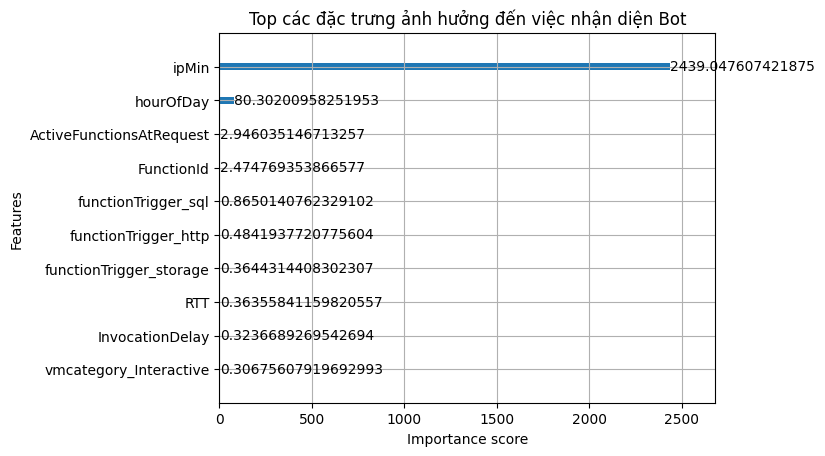

In [135]:
import xgboost as xgb
from xgboost import plot_importance
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu
# X_df là các cột đặc trưng, Y_df là cột 'bot'
cols_to_drop = ['bot', 'dayOfWeek', 'ipDay', 'ipWeek', 'ipHour']
X_df = df.drop(columns=cols_to_drop)
Y_df = df['bot']

# 2. Xử lý mất cân bằng (Imbalance)
# Công thức: scale_pos_weight = số lượng mẫu 0 / số lượng mẫu 1
# Với dữ liệu của bạn: 56015 / 131072
ratio = 56015 / 131072

# 3. Khởi tạo và huấn luyện mô hình
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio, # Giúp mô hình không bị "nghiêng" về phía Bot
    random_state=42,
    importance_type='gain',  # Tập trung vào cột nào giúp tăng độ chính xác nhất
    enable_categorical=True
)

model.fit(X_df, Y_df)

# 4. Lấy bảng trọng số (Feature Importance Table)
importance_scores = model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame(
    list(importance_scores.items()), 
    columns=['Feature', 'Gain Score']
).sort_values(by='Gain Score', ascending=False)

print("Bảng trọng số các cột ảnh hưởng nhất:")
print(importance_df)

# 5. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Top các đặc trưng ảnh hưởng đến việc nhận diện Bot")
plt.show()

## Model Input

Feed the matrix into a deep learning model (e.g., attention-based)

### Kiến trúc Transformer

In [136]:
import torch
import torch.nn as nn

class TabularTokenizer(nn.Module):
    def __init__(self, num_features, vocab_size, d, k):
        super().__init__()
        # 1. Value Embedding (Map giá trị normalized integer -> vector d)
        self.value_embed = nn.Embedding(num_embeddings=vocab_size, embedding_dim=d)
        # 2. Feature Embedding (Map column identity -> vector k)
        self.feature_embed = nn.Embedding(num_embeddings=num_features, embedding_dim=k)
        # Lưu lại ID của các cột (0, 1, 2, 3...)
        self.register_buffer('feature_ids', torch.arange(num_features))

    def forward(self, x):
        # x là 1 batch dữ liệu đã được Discretize thành số nguyên
        v_value = self.value_embed(x) 
        v_feature = self.feature_embed(self.feature_ids).unsqueeze(0).expand(x.size(0), -1, -1)
        # 3. Combine: Concatenate dọc theo chiều cuối cùng (v_value || v_feature)
        v_out = torch.cat([v_value, v_feature], dim=-1)
        # 4. Row Representation: Trả về một Ma trận sẵn sàng ném vào lớp Attention
        return v_out

In [137]:
# ==========================================
# BƯỚC 1: KHỞI TẠO MODEL
# ==========================================
# Cài đặt thông số kiến trúc
NUM_FEATURES = 24    # num_features: Có bao nhiêu cột feature?
VOCAB_SIZE = 51      # vocab_size: Giá trị integer lớn nhất trong data + 1 (chạy từ 0 -> 50)
DIM_VALUE = 8        # d: Độ dài vector d (từ)? (ví dụ 8)
DIM_FEATURE = 4      # k: Độ dài vector k (cột)? (ví dụ 4)

# Khởi tạo (Lúc này máy tính bắt đầu cấp phát RAM để tạo các ma trận Embedding)
tokenizer = TabularTokenizer(num_features=NUM_FEATURES, 
                             vocab_size=VOCAB_SIZE, 
                             d=DIM_VALUE, 
                             k=DIM_FEATURE)

print("Đã tạo xong Model!")

# ==========================================
# BƯỚC 2: CHẠY DỮ LIỆU (Gọi hàm forward)
# ==========================================
# Giả lập một mini-batch gồm 32 dòng log mạng (batch_size = 32), mỗi dòng có 24 tính năng.
# Data bây giờ toàn là số nguyên (từ 0 đến 100) đã rời rạc hóa.
dummy_data_x = torch.randint(low=0, high=50, size=(32, NUM_FEATURES))

print(f"Hình thù Data lúc mới vào: {dummy_data_x.shape} -> (32 dòng, 24 cột số nguyên)")

# Ném data vào model (Nó sẽ tự động chạy hàm forward)
embedded_matrix = tokenizer(dummy_data_x)

# ==========================================
# BƯỚC 3: XEM KẾT QUẢ
# ==========================================
print(f"Hình thù Data sau khi nhúng: {embedded_matrix.shape}")

Đã tạo xong Model!
Hình thù Data lúc mới vào: torch.Size([32, 24]) -> (32 dòng, 24 cột số nguyên)
Hình thù Data sau khi nhúng: torch.Size([32, 24, 12])


In [138]:
class DoW_Classifier(nn.Module):
    def __init__(self, tokenizer, num_features, embedding_dim):
        super().__init__()
        self.tokenizer = tokenizer
        
        # 1. Lớp Transformer Encoder (Trái tim của mô hình)
        # Bác có 24 vector, mỗi vector dài 12 (d_model = 12)
        encoder_layer = nn.TransformerEncoderLayer(d_model=12, nhead=4, batch_first=True)
        # Chồng 2 lớp lên nhau cho máy học sâu hơn
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # 2. Lớp Gom data (Flatten)
        # Biến ma trận 2D thành vector 1D dài thòng lòng (24 * 12 = 288)
        self.flatten = nn.Flatten()

        input_dim = num_features * embedding_dim
        
        # 3. Lớp Đầu ra (Dự đoán)
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),   # Đầu ra duy nhất 1 con số (Xác suất bot)
            nn.Sigmoid()        # Ép xác suất về khoảng [0, 1]
        )

    def forward(self, x):
        # Bước 1: Biến số thành ma trận [32, 24, 12]
        embedded = self.tokenizer(x) 
        
        # Bước 2: Cho máy học "sự chú ý" chéo giữa 24 cột
        attended = self.transformer(embedded) 
        
        # Bước 3: Đập dẹp và tính xác suất
        flat = self.flatten(attended)
        out = self.classifier(flat)
        return out

In [139]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# 1. Chốt sổ các cột mang đi Train (Loại bỏ 2 "kẻ phản bội" gây rò rỉ dữ liệu)
# Mạnh dạn loại bỏ hoàn toàn các cột mang tính định danh và thời gian
cols_to_drop = ['bot', 'dayOfWeek', 'ipDay', 'ipWeek', 'ipHour']
X_df = df.drop(columns=cols_to_drop)

# Ép toàn bộ bảng về số nguyên (int) để an toàn ném vào lớp Embedding
X = X_df.astype(int).values 
y = df['bot'].astype(int).values

print(f"Tổng số tính năng (cột) mang đi đánh trận: {X.shape[1]}")

# 2. Chia tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Ép kiểu sang PyTorch Tensor và đẩy lên GPU
# Tính năng (X) phải là số nguyên (.long) | Nhãn (y) phải là số thực (.float)
X_train_tensor = torch.tensor(X_train).long().to(device)
y_train_tensor = torch.tensor(y_train).float().unsqueeze(1).to(device) # unsqueeze(1) biến [N] thành [N, 1]

X_test_tensor = torch.tensor(X_test).long().to(device)
y_test_tensor = torch.tensor(y_test).float().unsqueeze(1).to(device)

# 4. Tạo DataLoader (Máy dập batch)
# Vì dùng GPU mạnh, bác có thể quất Batch Size to (512 hoặc 1024) cho nó học lẹ
BATCH_SIZE = 1024 
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) # Shuffle để xáo trộn câu hỏi
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Đã đóng gói xong! Tổng số mẻ (batches) mỗi Epoch: {len(train_loader)}")

cuda
Tổng số tính năng (cột) mang đi đánh trận: 23
Đã đóng gói xong! Tổng số mẻ (batches) mỗi Epoch: 147


In [140]:
import torch.nn as nn
import torch.optim as optim

# ==========================================
# KHỞI TẠO LẠI MODEL CHO KHỚP DATA THẬT
# ==========================================
NUM_FEATURES = X.shape[1] # Lấy tự động số lượng cột
EMBED_DIM = DIM_VALUE + DIM_FEATURE # 8 + 4 = 12
VOCAB_SIZE = int(X.max()) + 1 # Tính tự động kích thước từ điển (thường là 51)

print(f"Setup Model: {NUM_FEATURES} features, Vocab size: {VOCAB_SIZE}")

tokenizer = TabularTokenizer(num_features=NUM_FEATURES, vocab_size=VOCAB_SIZE, d=8, k=4)
model = DoW_Classifier(tokenizer, num_features=NUM_FEATURES, embedding_dim=EMBED_DIM).to(device)

# Tính trọng số: Số lượng mẫu 0 / Số lượng mẫu 1
weight_tensor = torch.tensor([56015 / 131072]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=weight_tensor) 
optimizer = optim.Adam(model.parameters(), lr=0.001) 

EPOCHS = 10 # Chơi luôn 10 Epochs xem độ ảo

# ==========================================
# TRAINING THỰC CHIẾN
# ==========================================
print("\n--- BẮT ĐẦU HUẤN LUYỆN ---")
model.train() 

for epoch in range(EPOCHS):
    total_loss = 0
    
    # Lặp qua từng mẻ dữ liệu trong DataLoader
    for batch_X, batch_y in train_loader:
        
        optimizer.zero_grad()            # 1. Reset đạo hàm
        predictions = model(batch_X)     # 2. Dự đoán
        loss = criterion(predictions, batch_y) # 3. Chấm điểm
        loss.backward()                  # 4. Truy vết lỗi
        optimizer.step()                 # 5. Cập nhật Weights
        
        total_loss += loss.item()
        
    # Tính trung bình Loss của cả Epoch
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Điểm Loss Trung Bình: {avg_loss:.4f}")

print("🚀 Huấn luyện xong!")

Setup Model: 23 features, Vocab size: 51

--- BẮT ĐẦU HUẤN LUYỆN ---
Epoch [1/10], Điểm Loss Trung Bình: 0.3172
Epoch [2/10], Điểm Loss Trung Bình: 0.3018
Epoch [3/10], Điểm Loss Trung Bình: 0.3017
Epoch [4/10], Điểm Loss Trung Bình: 0.3018
Epoch [5/10], Điểm Loss Trung Bình: 0.3017
Epoch [6/10], Điểm Loss Trung Bình: 0.3016
Epoch [7/10], Điểm Loss Trung Bình: 0.3015
Epoch [8/10], Điểm Loss Trung Bình: 0.3015
Epoch [9/10], Điểm Loss Trung Bình: 0.3017
Epoch [10/10], Điểm Loss Trung Bình: 0.3016
🚀 Huấn luyện xong!


--- BÁO CÁO KẾT QUẢ ---
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     11203
         1.0       1.00      1.00      1.00     26215

    accuracy                           1.00     37418
   macro avg       1.00      1.00      1.00     37418
weighted avg       1.00      1.00      1.00     37418



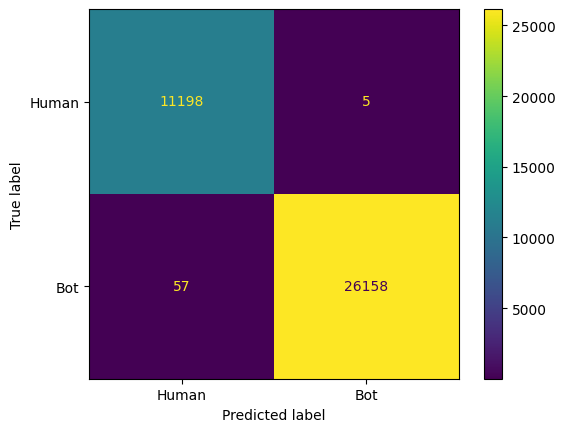

In [148]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

model.eval() # Chuyển sang chế độ kiểm tra
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        # Chuyển xác suất thành nhãn 0 hoặc 1 (ngưỡng 0.5)
        preds = (outputs > 0.8).float()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# In báo cáo chi tiết
print("--- BÁO CÁO KẾT QUẢ ---")
print(classification_report(all_labels, all_preds))

ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_preds,
    display_labels=["Human", "Bot"]
)